# Notebook 3 — Predição no Banco de Dados de Teste

**Entrada:**
- `database/test_processed.csv` — dados de teste tratados (Notebook 1)
- `models/` — modelos, scaler e metadados (Notebook 2)

**Objetivo:** Avaliar o desempenho dos modelos treinados no conjunto de teste, identificar e tratar outliers de preço, gerar previsões para registros sem preço e salvar o resultado final.

**Saída:** `previsoes_finais.csv`

In [1]:
# Instalar dependências caso não estejam presentes
import subprocess, sys
pkgs = ["seaborn", "xgboost", "lightgbm"]
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + pkgs)
print("Dependências OK")

Dependências OK


## 1. Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='whitegrid')
print('Imports concluídos.')

Imports concluídos.


## 2. Carregar modelos, scaler e metadados

In [3]:
scaler = joblib.load('models/scaler.pkl')

with open('models/colunas_treino.json', 'r') as f:
    colunas_treino = json.load(f)

with open('models/metadados_treino.json', 'r') as f:
    meta = json.load(f)

modelos = {
    'Ridge'             : joblib.load('models/modelo_ridge.pkl'),
    'Random Forest'     : joblib.load('models/modelo_random_forest.pkl'),
    'Gradient Boosting' : joblib.load('models/modelo_gradient_boosting.pkl'),
    'XGBoost'           : joblib.load('models/modelo_xgboost.pkl'),
    'LightGBM'          : joblib.load('models/modelo_lightgbm.pkl'),
    'Ensemble'          : joblib.load('models/modelo_ensemble.pkl'),
}

LIMITE_PRECO  = meta['p99_preco']
MELHOR_MODELO = meta['melhor_modelo']

print('✅ Modelos carregados:')
for nome in modelos:
    print(f'   - {nome}')
print(f'\nColunas do treino  : {len(colunas_treino)}')
print(f'Limite de preço    : R$ {LIMITE_PRECO:,.0f} (p99 do treino)')
print(f'Melhor modelo      : {MELHOR_MODELO}')
print(f'R² validação       : {meta["r2_validacao"]}')

✅ Modelos carregados:
   - Ridge
   - Random Forest
   - Gradient Boosting
   - XGBoost
   - LightGBM
   - Ensemble

Colunas do treino  : 102
Limite de preço    : R$ 85,026 (p99 do treino)
Melhor modelo      : Ensemble
R² validação       : 0.71


## 3. Carregar dados de teste

In [4]:
df_test = pd.read_csv('database/test_processed.csv')

print(f'Teste shape: {df_test.shape}')
df_test.head()

Teste shape: (17370, 26)


,ID,Débitos,Fabricante,Modelo,Ano,Categoria,Couro,Combustivel,Volume_motor,Km,...,Airbags,Preco,Numero_proprietarios,Data_ultima_lavagem,Adesivos_personalizados,Radio_AM_FM,Historico_troca_oleo,Codigo_concessionaria,Classificacao_Veiculo,Faixa_Preco
0,45804429,1017,HYUNDAI,Tucson,2017,SUV,Sim,Diesel,2.0,48089.0,...,4,40556.0,5,2022-11-19,Não,FM,8,4776,Usado,Médio
1,45768909,0,MERCEDES-BENZ,C 180,1995,Sedan,Nao,Gasolina,1.8,NaN,...,2,5331.0,2,2021-09-30,Sim,FM,1,7983,Usado,Econômico
2,45788796,836,BMW,118,2010,Sedan,Sim,Diesel,2.0,197000.0,...,0,18817.0,5,2021-05-08,Sim,AM,6,2664,Usado,Econômico
3,42974578,891,KIA,Sportage SX,2016,SUV,Sim,Gasolina,2.0,55447.0,...,10,22894.0,5,2021-06-11,Não,FM,5,8234,Usado,Médio
4,45801622,583,HYUNDAI,Elantra,2011,Sedan,Sim,Gasolina,1.6,106616.0,...,4,20005.0,1,2021-12-05,Sim,AM,1,5769,Usado,Médio


In [5]:
# Separar registros com preço (avaliação) e sem preço (predição pura)
df_com_preco  = df_test[df_test['Preco'].notna()].copy()
df_sem_preco  = df_test[df_test['Preco'].isna()].copy()

print(f'Com preço (avaliação) : {len(df_com_preco)}')
print(f'Sem preço (predição)  : {len(df_sem_preco)}')

Com preço (avaliação) : 9090
Sem preço (predição)  : 8280


## 4. Função de pré-processamento

In [6]:
with open('database/anova_colunas_remover.json', 'r', encoding='utf-8') as f:
    colunas_remover = json.load(f)


def preprocessar(df_raw: pd.DataFrame, tem_preco: bool = True):
    """
    Aplica o mesmo pipeline do treino:
    1. Remove colunas indicadas pela ANOVA
    2. Corrige tipos
    3. Encoda categóricas
    4. Alinha colunas com o treino
    5. Escala

    Retorna (X_scaled, y) onde y é None se tem_preco=False.
    """
    df = df_raw.copy()
    df = df.drop(columns=[c for c in colunas_remover if c in df.columns])

    # Corrigir tipos
    for col in ['Débitos', 'Km', 'Volume_motor']:
        if col in df.columns:
            df[col] = pd.to_numeric(
                df[col].astype(str).str.replace('-', '0', regex=False)
                if col == 'Débitos'
                else df[col],
                errors='coerce'
            )

    y = df['Preco'].copy() if tem_preco and 'Preco' in df.columns else None
    df = df.drop(columns=['Preco'], errors='ignore')

    # Encodar categóricas
    cat_cols = df.select_dtypes(include='object').columns.tolist()
    df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

    # Converter bool → int
    df = df.astype({c: int for c in df.select_dtypes(include='bool').columns})
    df = df.select_dtypes(include='number')

    # Alinhar com as colunas do treino
    df = df.reindex(columns=colunas_treino, fill_value=0)
    df = df.fillna(df.median())

    X_scaled = scaler.transform(df)
    return X_scaled, y


print('Função de pré-processamento definida.')

Função de pré-processamento definida.


## 5. Avaliação dos modelos — registros com preço dentro do range do treino

In [7]:
X_eval, y_eval = preprocessar(df_com_preco, tem_preco=True)

# Filtrar apenas preços dentro do range do treino
mask_valido = y_eval.values <= LIMITE_PRECO

print(f'Registros avaliados: {mask_valido.sum()} de {len(y_eval)}')
print(f'Fora do range (> R$ {LIMITE_PRECO:,.0f}): {(~mask_valido).sum()}\n')

print(f'{"Modelo":<22} {"R²":>8} {"RMSE":>12} {"MAE":>12}')
print('-' * 58)

resultados_teste = []
for nome, modelo in modelos.items():
    y_pred   = modelo.predict(X_eval)[mask_valido]
    y_real   = y_eval.values[mask_valido]
    r2       = r2_score(y_real, y_pred)
    rmse     = np.sqrt(mean_squared_error(y_real, y_pred))
    mae      = mean_absolute_error(y_real, y_pred)
    resultados_teste.append({'Modelo': nome, 'R²': r2, 'RMSE': rmse, 'MAE': mae})
    print(f'{nome:<22} {r2:>8.4f} {rmse:>12,.0f} {mae:>12,.0f}')

df_resultados = pd.DataFrame(resultados_teste)

Registros avaliados: 8988 de 9090
Fora do range (> R$ 85,026): 102

Modelo                       R²         RMSE          MAE
----------------------------------------------------------
Ridge                  -5101.6177    1,070,350       43,898
Random Forest            0.6682        8,631        5,661


C:\Users\Lucas\AppData\Local\Temp\ipykernel_21096\3202310311.py:33: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()
c:\Users\Lucas\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
c:\Users\Lucas\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was f

Gradient Boosting        0.6566        8,781        5,579
XGBoost                  0.6953        8,271        5,276
LightGBM                 0.6806        8,468        5,332
Ensemble                 0.6975        8,241        5,239


c:\Users\Lucas\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Lucas\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


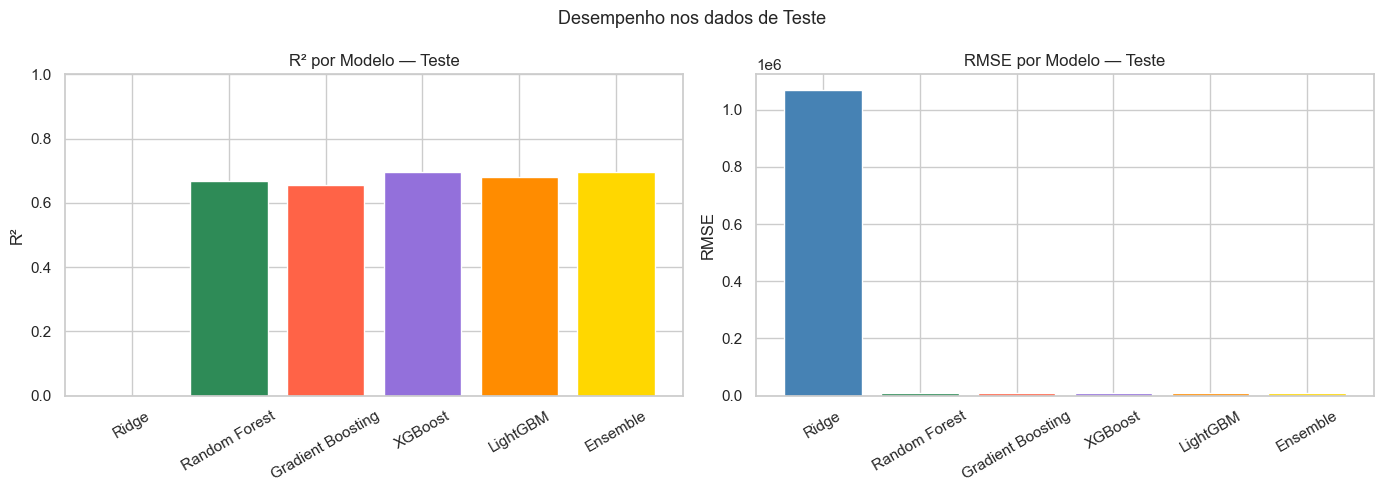

In [8]:
# Gráfico de comparação
cores = ['steelblue', 'seagreen', 'tomato', 'mediumpurple', 'darkorange', 'gold']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(df_resultados['Modelo'], df_resultados['R²'],
            color=cores[:len(df_resultados)], edgecolor='white')
axes[0].set_title('R² por Modelo — Teste')
axes[0].set_ylabel('R²')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(df_resultados['Modelo'], df_resultados['RMSE'],
            color=cores[:len(df_resultados)], edgecolor='white')
axes[1].set_title('RMSE por Modelo — Teste')
axes[1].set_ylabel('RMSE')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Desempenho nos dados de Teste', fontsize=13)
plt.tight_layout()
plt.savefig('teste_comparacao_modelos.png', dpi=150)
plt.show()

🏆 Melhor modelo no teste: Ensemble


c:\Users\Lucas\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Lucas\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


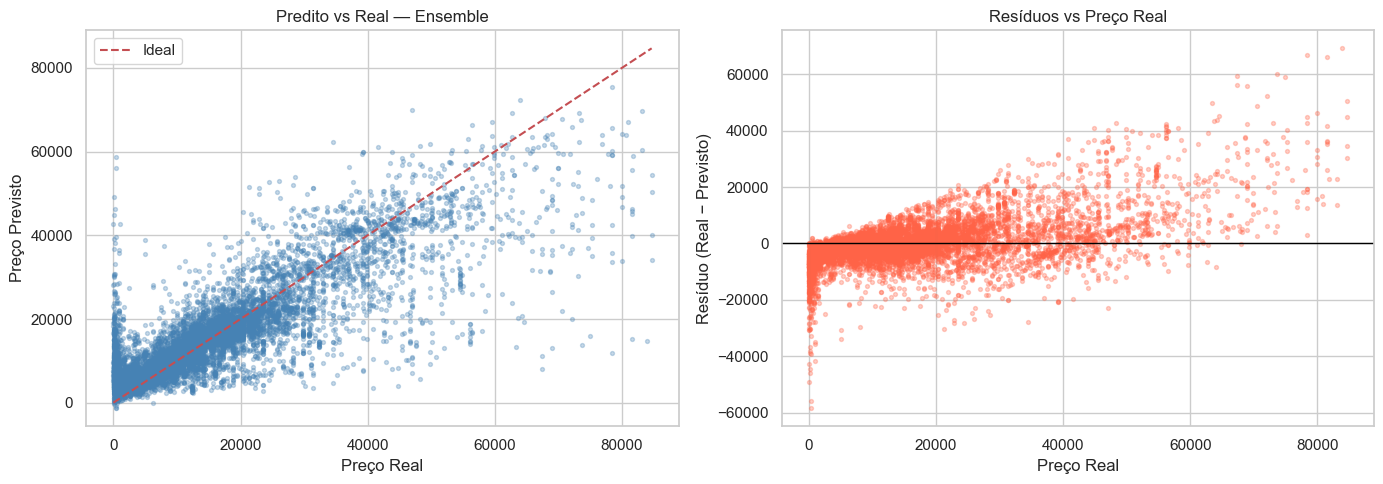

In [9]:
# Gráfico predito vs real — melhor modelo no teste
melhor_teste = df_resultados.loc[df_resultados['R²'].idxmax(), 'Modelo']
print(f'🏆 Melhor modelo no teste: {melhor_teste}')

y_pred_melhor = modelos[melhor_teste].predict(X_eval)[mask_valido]
y_real_melhor = y_eval.values[mask_valido]
residuos = y_real_melhor - y_pred_melhor

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_real_melhor, y_pred_melhor, alpha=0.3, s=8, color='steelblue')
axes[0].plot([y_real_melhor.min(), y_real_melhor.max()],
             [y_real_melhor.min(), y_real_melhor.max()], 'r--', label='Ideal')
axes[0].set_xlabel('Preço Real')
axes[0].set_ylabel('Preço Previsto')
axes[0].set_title(f'Predito vs Real — {melhor_teste}')
axes[0].legend()

axes[1].scatter(y_real_melhor, residuos, alpha=0.3, s=8, color='tomato')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_xlabel('Preço Real')
axes[1].set_ylabel('Resíduo (Real − Previsto)')
axes[1].set_title('Resíduos vs Preço Real')

plt.tight_layout()
plt.savefig('teste_predito_vs_real.png', dpi=150)
plt.show()

## 6. Diagnóstico por faixa de preço

In [10]:
df_diag = pd.DataFrame({
    'Preco_Real': y_real_melhor,
    'Residuo'   : residuos,
    'Faixa'     : pd.cut(y_real_melhor, bins=5),
})

print('Resíduo médio por faixa de preço:')
print(df_diag.groupby('Faixa', observed=True)['Residuo']
      .agg(['mean', 'std', 'count']).round(0))

Resíduo médio por faixa de preço:
                       mean      std  count
Faixa                                      
(-83.674, 16935.8]  -2636.0   5194.0   5606
(16935.8, 33870.6]   1831.0   7040.0   2270
(33870.6, 50805.4]   5603.0  10974.0    775
(50805.4, 67740.2]  14611.0  13172.0    247
(67740.2, 84675.0]  26884.0  15807.0     90


## 7. Predição para outliers de preço (acima do range do treino)

In [11]:
mask_outlier   = y_eval.values > LIMITE_PRECO
df_outliers    = df_com_preco.iloc[mask_outlier].copy()

if len(df_outliers) > 0:
    X_outliers, _  = preprocessar(df_outliers, tem_preco=False)
    prev_outliers  = modelos[melhor_teste].predict(X_outliers)

    df_outliers_res = pd.DataFrame({
        'ID'             : df_outliers['ID'].values if 'ID' in df_outliers.columns else range(len(df_outliers)),
        'Preco_Original' : df_outliers['Preco'].values,
        'Preco_Previsto' : prev_outliers.round(2),
        'Origem'         : 'Outlier corrigido',
    })

    print(f'Outliers de preço corrigidos: {len(df_outliers_res)}')
    print(df_outliers_res.to_string(index=False))
else:
    df_outliers_res = pd.DataFrame()
    print('Nenhum outlier de preço encontrado no conjunto de avaliação.')

Outliers de preço corrigidos: 102
      ID  Preco_Original  Preco_Previsto            Origem
45802550         95739.0        66542.52 Outlier corrigido
45748414        141124.0        58130.71 Outlier corrigido
43374774        106627.0        59194.06 Outlier corrigido
45761401        172486.0        59574.56 Outlier corrigido
45229113        297930.0        61048.42 Outlier corrigido
45781828         98787.0        66665.82 Outlier corrigido
45808919         92070.0        57140.22 Outlier corrigido
45490304         89379.0        66008.60 Outlier corrigido
44266062         87811.0        42202.82 Outlier corrigido
45805870         93769.0        59545.28 Outlier corrigido
45804437         99440.0        37115.21 Outlier corrigido
45694885        103491.0        64947.81 Outlier corrigido
45785166        131716.0        18016.61 Outlier corrigido
45802548         98066.0        63437.72 Outlier corrigido
45809039        104216.0        31744.63 Outlier corrigido
45202115         97219

C:\Users\Lucas\AppData\Local\Temp\ipykernel_21096\3202310311.py:33: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()
c:\Users\Lucas\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Lucas\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegress

## 8. Predição para registros sem preço

In [12]:
if len(df_sem_preco) > 0:
    X_pred, _      = preprocessar(df_sem_preco, tem_preco=False)
    prev_sem_preco = modelos[melhor_teste].predict(X_pred)

    df_sem_preco_res = pd.DataFrame({
        'ID'             : df_sem_preco['ID'].values if 'ID' in df_sem_preco.columns else range(len(df_sem_preco)),
        'Preco_Original' : np.nan,
        'Preco_Previsto' : prev_sem_preco.round(2),
        'Origem'         : 'Sem preço original',
    })
    print(f'Registros sem preço previstos: {len(df_sem_preco_res)}')
else:
    df_sem_preco_res = pd.DataFrame()
    print('Nenhum registro sem preço no conjunto de teste.')

C:\Users\Lucas\AppData\Local\Temp\ipykernel_21096\3202310311.py:33: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()
c:\Users\Lucas\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Registros sem preço previstos: 8280


c:\Users\Lucas\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


## 9. Consolidar e salvar resultado final

In [13]:
partes = [p for p in [df_sem_preco_res, df_outliers_res] if len(p) > 0]

if partes:
    df_final = pd.concat(partes, ignore_index=True)
    df_final.to_csv('previsoes_finais.csv', index=False)

    print('✅ PREVISÕES FINAIS SALVAS EM previsoes_finais.csv')
    print(f'   Sem preço original  : {len(df_sem_preco_res)}')
    print(f'   Outliers corrigidos : {len(df_outliers_res)}')
    print(f'   Total               : {len(df_final)}')
    print()
    print('Amostra:')
    print(df_final.head(10).to_string(index=False))
else:
    print('Nenhuma previsão para salvar — todos os registros de teste possuem preço no range do treino.')

✅ PREVISÕES FINAIS SALVAS EM previsoes_finais.csv
   Sem preço original  : 8280
   Outliers corrigidos : 102
   Total               : 8382

Amostra:
      ID  Preco_Original  Preco_Previsto             Origem
45809891             NaN        42895.96 Sem preço original
45619226             NaN         4501.40 Sem preço original
45810400             NaN        29037.26 Sem preço original
45241160             NaN        12763.13 Sem preço original
45532883             NaN         5970.58 Sem preço original
45796070             NaN         9625.78 Sem preço original
45803811             NaN        40546.75 Sem preço original
45760764             NaN        14503.86 Sem preço original
45768973             NaN        18955.32 Sem preço original
45813968             NaN         2943.73 Sem preço original


## 10. Resumo final dos resultados no teste

In [14]:
print('=' * 60)
print('RESUMO — DESEMPENHO NO CONJUNTO DE TESTE')
print('=' * 60)
print(df_resultados.sort_values('R²', ascending=False).to_string(index=False))
print()
print(f'Melhor modelo   : {melhor_teste}')
r2_melhor = df_resultados.loc[df_resultados['Modelo'] == melhor_teste, 'R²'].values[0]
rmse_melhor = df_resultados.loc[df_resultados['Modelo'] == melhor_teste, 'RMSE'].values[0]
mae_melhor = df_resultados.loc[df_resultados['Modelo'] == melhor_teste, 'MAE'].values[0]
print(f'R²              : {r2_melhor:.4f}')
print(f'RMSE            : R$ {rmse_melhor:,.0f}')
print(f'MAE             : R$ {mae_melhor:,.0f}')
print('=' * 60)

RESUMO — DESEMPENHO NO CONJUNTO DE TESTE
           Modelo           R²         RMSE          MAE
         Ensemble     0.697503 8.241192e+03  5239.476656
          XGBoost     0.695308 8.271028e+03  5276.307850
         LightGBM     0.680609 8.468189e+03  5331.646840
    Random Forest     0.668215 8.630930e+03  5660.881918
Gradient Boosting     0.656587 8.780867e+03  5578.527075
            Ridge -5101.617714 1.070350e+06 43897.679337

Melhor modelo   : Ensemble
R²              : 0.6975
RMSE            : R$ 8,241
MAE             : R$ 5,239
